In [45]:
import math

class RadiativeTransfer:
    T_VALUES = [2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
    K_VALUES = [
        1.600E+00, 5.400E+00, 1.280E+01, 2.500E+01,
        4.320E+01, 6.860E+01, 1.024E+02, 1.458E+02, 2.000E+02
    ]
    
    # T_VALUES = [2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
    # 
    # K_VALUES = [
    #     8.200e-03, 2.768e-02, 6.560e-02, 1.281e-01,
    #     2.214e-01, 3.516e-01, 5.248e-01, 7.472e-01, 1.025e+00
    # ]

    def __init__(self, c, R, Tw, T0, k0, p, m):
        self.c = c
        self.R = R
        self.Tw = Tw
        self.T0 = T0
        self.k0 = k0
        self.p = p
        self.m = m

    def logInterp(self, TNew):
        logT = [math.log(t) for t in self.T_VALUES]
        logK = [math.log(k) for k in self.K_VALUES]
        logTNew = math.log(TNew)

        for i in range(len(logT) - 1):
            if logT[i] <= logTNew <= logT[i + 1]:
                logKNew = logK[i] + (logK[i + 1] - logK[i]) * (logTNew - logT[i]) / (logT[i + 1] - logT[i])
                return math.exp(logKNew)
        return math.exp(logK[-1])

    def temperature(self, z):
        return (self.Tw - self.T0) * pow(z, self.p) + self.T0

    def k(self, z):
        return self.logInterp(self.temperature(z))

    def uP(self, z):
        T = self.temperature(z)
        return 3.084e-4 / (math.exp(4.799e4 / T) - 1)

    def lambda_(self, zn):
        return self.c / (3 * self.k(zn))

    def p_(self, zn):
        return self.c * self.k(zn)

    def f(self, zn):
        return self.c * self.k(zn) * self.uP(zn)

    def kappa(self, zn, h):
        return (self.lambda_(zn) + self.lambda_(zn + h)) / 2

    def v(self, zn, h):
        return (pow(zn + h / 2, 2) - pow(zn - h / 2, 2)) / 2

    def A(self, zn, h):
        return (zn - h / 2) * self.kappa(zn - h, h) / (self.R ** 2 * h)

    def D(self, zn, h):
        return (zn + h / 2) * self.kappa(zn, h) / (self.R ** 2 * h)

    def B(self, zn, h):
        return self.A(zn, h) + self.D(zn, h) + self.p_(zn) * self.v(zn, h)

    def F(self, zn, h):
        return self.f(zn) * self.v(zn, h)

    def Ao(self, zn, h):
        return (zn + h / 2) / self.k(zn + h / 2) / h

    def Do(self, zn, h):
        return (zn - h / 2) / self.k(zn - h / 2) / h

    def Fo(self, zn, h):
        return 3 * (self.R ** 3) * h * zn * self.k(zn) * self.uP(zn)

    def Bo(self, zn, h):
        return self.A(zn, h) + self.D(zn, h) + 3 * (self.R ** 3) * h * zn * self.k(zn)

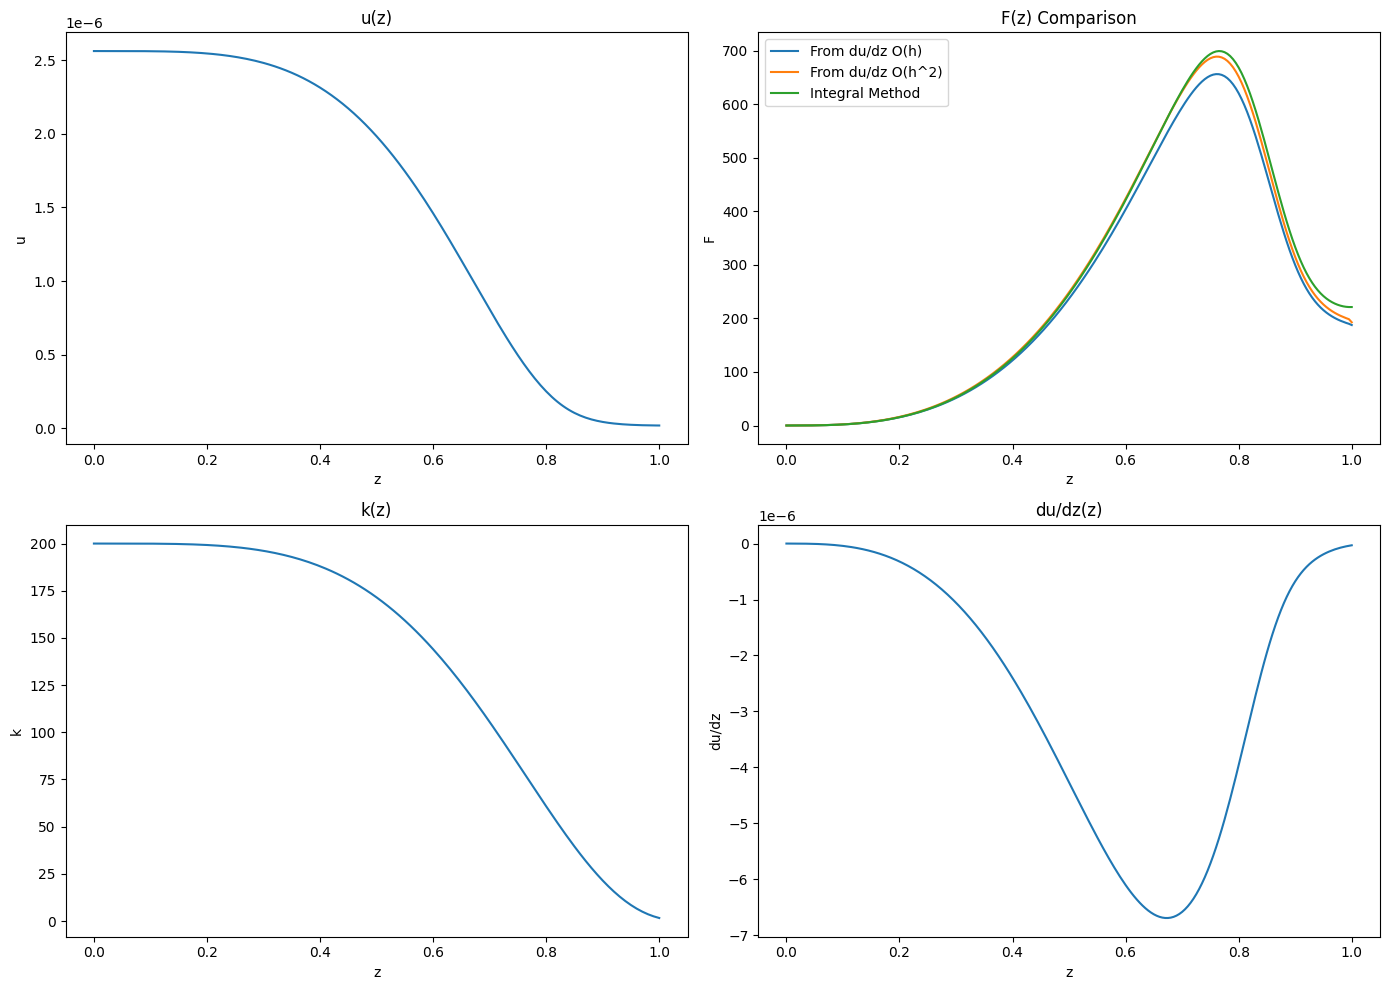

F_integral = 221.24842420208017
F_diff     = 192.75710294110345
F_diff_O1  = 187.64737558153746
F_boundary = 221.24828730186553


In [46]:
import numpy as np
import matplotlib.pyplot as plt


def thomas_algorithm(rt, N):
    h = 1.0 / N
    ksi = np.zeros(N + 1)
    eta = np.zeros(N + 1)
    y = np.zeros(N + 1)

    m0 = (rt.kappa(0.0, h) * h / 2.0) / (2.0 * rt.R ** 2 * h)
    k0 = -(rt.kappa(0.0, h) * h / 2.0) / (2.0 * rt.R ** 2 * h)
    q0 = 0.0

    ksi[1] = -k0 / m0
    eta[1] = q0 / m0

    for n in range(1, N):
        xn = n * h
        denom = rt.B(xn, h) - rt.A(xn, h) * ksi[n]
        ksi[n + 1] = rt.D(xn, h) / denom
        eta[n + 1] = (rt.F(xn, h) + rt.A(xn, h) * eta[n]) / denom

    alpha = 0.39 * 3 * rt.k(1.0) * h
    y[N] = eta[N] / (1 + alpha - ksi[N])

    for n in range(N - 1, -1, -1):
        y[n] = ksi[n + 1] * y[n + 1] + eta[n + 1]

    return y


def half_division_method(rt, initial_N, epsilon):
    N = initial_N
    max_iter = 500

    y_prev = thomas_algorithm(rt, N)
    for _ in range(max_iter):
        N *= 2
        y_curr = thomas_algorithm(rt, N)

        max_diff = max(
            abs(y_curr[i * 2] - y_prev[i])
            for i in range(len(y_prev))
        )

        if max_diff < epsilon:
            return N, y_curr

        y_prev = y_curr

    return N, y_curr


def execute():
    rt = RadiativeTransfer(3e10, 0.35, 2000, 10000, 1e-4, 4, 0.39)
    eps = 1e-8
    N, y = half_division_method(rt, 100, eps)
    h = 1.0 / N

    z = np.linspace(0, 1, N + 1)
    u = y
    uP = np.array([rt.uP(zi) for zi in z])
    k = np.array([rt.k(zi) for zi in z])

    duDz = np.zeros(N + 1)
    duDzO1 = np.zeros(N + 1)

    for i in range(N + 1):
        if i == 0:
            duDz[i] = duDzO1[i] = (u[i + 1] - u[i]) / h
        elif i == N:
            duDz[i] = (3 * u[i] - 4 * u[i - 1] + u[i - 2]) / (2 * h)
            duDzO1[i] = (u[i] - u[i - 1]) / h
        else:
            duDz[i] = (u[i + 1] - u[i - 1]) / (2 * h)
            duDzO1[i] = (u[i] - u[i - 1]) / h

    # integrand = -k * (u - uP)
    integrand = - z * k * (u - uP)
    integral = np.zeros(N + 1)
    F_integral = np.zeros(N + 1)

    for i in range(1, N + 1):
        integral[i] = integral[i - 1] + (integrand[i - 1] + integrand[i]) * h / 2
        F_integral[i] = 0 if z[i] < eps else (rt.R * rt.c / (3 * z[i])) * integral[i]

    if N >= 2:
        lastIntegral = (h / 3) * (integrand[N - 2] + 4 * integrand[N - 1] + integrand[N])
        integral[N] += lastIntegral - (integrand[N - 1] + integrand[N]) * h / 2
        F_integral[N] = (rt.R * rt.c / (3 * z[N])) * integral[N]
        
    integrand = - z * k * (u - uP)

    # if N % 2 == 1:
    #     raise ValueError("Simpson's rule requires even N")
    # 
    # integral_value = 0
    # for i in range(0, N, 2):
    #     integral_value += (integrand[i] + 4 * integrand[i + 1] + integrand[i + 2])
    # 
    # integral_value *= h / 3
    # F_simpson = (rt.R * rt.c / (3 * z[N])) * integral_value


    F_diff = np.where(k != 0, -rt.c * duDz / (3.0 * k), 0.0)
    F_diff_O1 = np.where(k != 0, -rt.c * duDzO1 / (3.0 * k), 0.0)

    # Plot
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))

    axs[0, 0].plot(z, u)
    axs[0, 0].set_title("u(z)")
    axs[0, 0].set_xlabel("z")
    axs[0, 0].set_ylabel("u")

    axs[0, 1].plot(z, F_integral, label="From du/dz O(h)")
    axs[0, 1].plot(z, F_diff, label="From du/dz O(h^2)")
    axs[0, 1].plot(z, F_diff_O1, label="Integral Method")
    axs[0, 1].set_title("F(z) Comparison")
    axs[0, 1].set_xlabel("z")
    axs[0, 1].set_ylabel("F")
    axs[0, 1].legend()
    
    from_div1 = F_diff[-1]
    from_div2 = F_integral[-1]
    from_integral = F_diff_O1[-1]

    axs[1, 0].plot(z, k)
    axs[1, 0].set_title("k(z)")
    axs[1, 0].set_xlabel("z")
    axs[1, 0].set_ylabel("k")

    axs[1, 1].plot(z, duDz)
    axs[1, 1].set_title("du/dz(z)")
    axs[1, 1].set_xlabel("z")
    axs[1, 1].set_ylabel("du/dz")

    plt.tight_layout()
    plt.show()
    
    alpha = 0.39 * 3 * k[-1]
    F_boundary = (rt.c / 3) * alpha * (u[-1] - uP[-1]) / k[-1]
    
    print("F_integral =", from_integral)
    print("F_diff     =", from_div1)
    print("F_diff_O1  =", from_div2)
    print("F_boundary =", F_boundary)


execute()